In [10]:
from transformers import AutoModelForCausalLM, AutoProcessor, GenerationConfig
from PIL import Image
import requests
import torch
from cotracker.predictor import CoTrackerPredictor
import copy

# load the processor
processor = AutoProcessor.from_pretrained(
    "allenai/Molmo-7B-D-0924",
    trust_remote_code=True,
    torch_dtype="auto",
    device_map="auto",
)

# load the model
model = AutoModelForCausalLM.from_pretrained(
    "allenai/Molmo-7B-D-0924",
    trust_remote_code=True,
    torch_dtype="auto",
    device_map="auto",
)

cotracker_ckpt_file = (
    "/scr/matthewh6/robot_learning/robot_learning/data/optical_flow/scaled_offline.pth"
)
cotracker = CoTrackerPredictor(checkpoint=cotracker_ckpt_file)
cotracker = cotracker.to("cuda")

/scr/matthewh6/miniconda3/envs/pref/lib/python3.9/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2025-07-16 17:45:02.309140: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-16 17:45:02.309189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-16 17:45:02.310600: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-16 17:45:02.317144: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use availab

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

paths = [
         "/tmp/square_500/square/demo_src_square_task_D0_r_Panda/demo.hdf5"]

for path in paths:
    with h5py.File(path, "a") as f:  # open in append mode so we can add new data
        demo_keys = list(f["data"].keys())
        demo_keys_sorted = sorted(demo_keys, key=lambda k: int(k.split("_")[-1]))

        num_demos = 0
        for demo_key in demo_keys_sorted:
            # print last couple of actions
            video = f["data"][demo_key]["obs"]["agentview_image"][:]
            init_frame = video[0]
            init_frame = Image.fromarray(init_frame, "RGB")

            # process the image and text
            inputs = processor.process(
                images=[init_frame], text="Point to the center of the square-shaped block with a handle."
            )
            

            # move inputs to the correct device and make a batch of size 1
            inputs = {k: v.to(model.device).unsqueeze(0) for k, v in inputs.items()}

            # generate output; maximum 200 new tokens; stop generation when <|endoftext|> is generated
            output = model.generate_from_batch(
                inputs,
                GenerationConfig(max_new_tokens=200, stop_strings="<|endoftext|>"),
                tokenizer=processor.tokenizer,
            )

            # only get generated tokens; decode them to text
            generated_tokens = output[0, inputs["input_ids"].size(1) :]
            generated_text = processor.tokenizer.decode(
                generated_tokens, skip_special_tokens=True
            )

            print(generated_text)

            # parse the generated text
            parsed_points = parse_points(generated_text)
            print(parsed_points)

            # scale the points
            scaled_parsed_points = scale_points_to_image(parsed_points, init_frame.size)
            print(scaled_parsed_points)

            draw_points_on_image(
                copy.deepcopy(init_frame), scaled_parsed_points, color=(255, 0, 0)
            )

            scaled_parsed_points = np.array(scaled_parsed_points)
            scaled_parsed_points = np.concatenate(
                [np.zeros((scaled_parsed_points.shape[0], 1)), scaled_parsed_points], axis=1
            )

            pred_points, pred_visibility = cotracker(
                torch.tensor(video).permute(0, 3, 1, 2)[None].float().to("cuda"),
                queries=torch.tensor(scaled_parsed_points[None]).float().to("cuda"),
                backward_tracking=True,
            )
            pred_points = pred_points[0].squeeze(1).cpu().numpy()

            group = f["data"][demo_key]
            if "goal_points" in group:
                continue

            group.create_dataset("goal_points", data=pred_points)
            print(f"Saved pred_points to {demo_key}/goal_points")


 <point x="71.0" y="34.0" alt="center of the square-shaped block with a handle">center of the square-shaped block with a handle</point>
[[0.71, 0.34]]
[[59.64, 28.560000000000002]]


In [6]:
# parse the generated text
parsed_points = parse_points(generated_text)
print(parsed_points)

# scale the points
scaled_parsed_points = scale_points_to_image(parsed_points, init_frame.size)
print(scaled_parsed_points)


draw_points_on_image(copy.deepcopy(init_frame), scaled_parsed_points, color=(255, 0, 0))

scaled_parsed_points = np.array(scaled_parsed_points)
scaled_parsed_points = np.concatenate(
    [np.zeros((scaled_parsed_points.shape[0], 1)), scaled_parsed_points], axis=1
)
s = torch.tensor(scaled_parsed_points[None]).float().to("cuda")
video = torch.tensor(video).permute(0, 3, 1, 2)[None].float().to("cuda")  # B T C H W

pred_points, pred_visibility = cotracker(video, queries=s, backward_tracking=True)

pred_points = pred_points[0].squeeze(1).cpu().numpy()

NameError: name 'generated_text' is not defined

In [5]:
import re
from PIL import ImageDraw


def parse_points(input_string):
    """
    Parses points from the input string, assuming the points are percentages of the image size.

    Parameters:
    - input_string: XML-like string containing the points as percentages.

    Returns:
    - List of (x, y) tuples in percentage form (0.0 to 1.0).
    """
    pattern = re.compile(r'x="([\d.]+)"\s+y="([\d.]+)"')
    points = [
        [float(match[0]) / 100, float(match[1]) / 100]
        for match in pattern.findall(input_string)
    ]
    return points


def scale_points_to_image(points, image_size):
    """
    Scales percentage-based points to actual pixel coordinates based on the image size.

    Parameters:
    - points: List of (x, y) tuples as percentages of the image size.
    - image_size: Tuple (width, height) of the image.

    Returns:
    - List of scaled (x, y) points in pixel coordinates.
    """
    width, height = image_size
    scaled_points = [[x * width, y * height] for x, y in points]
    return scaled_points


def draw_points_on_image(image, points, point_radius=3, color=(0, 255, 0)):
    """
    Draws points on a PIL image.

    Parameters:
    - image: The PIL image object.
    - points: List of (x, y) tuples representing points to draw.
    - point_radius: Radius of the points (default: 5).
    - color: RGB color of the points (default: red).

    Returns:
    - Image with the points drawn.
    """
    # Create a drawable object
    draw = ImageDraw.Draw(image)

    # Draw each point
    for x, y in points:
        upper_left = (x - point_radius, y - point_radius)
        lower_right = (x + point_radius, y + point_radius)
        draw.ellipse([upper_left, lower_right], fill=color)

    return image

In [12]:
video = video.squeeze(0).permute(0, 2, 3, 1).cpu().numpy()  # T H W C

ValueError: cannot select an axis to squeeze out which has size not equal to one

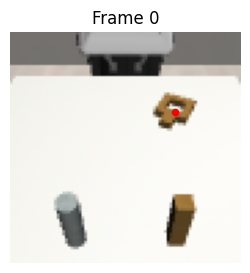

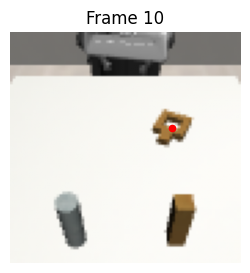

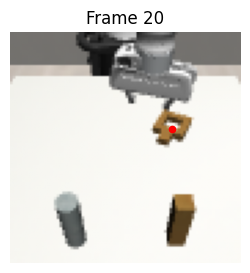

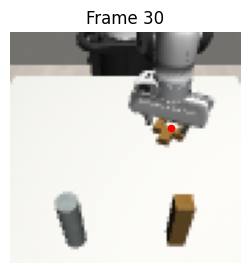

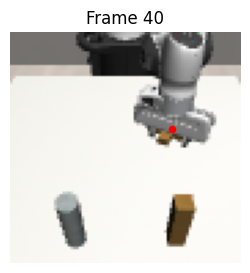

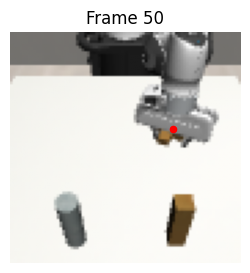

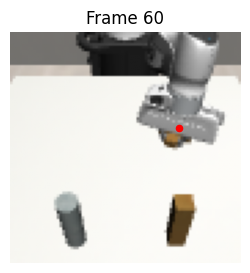

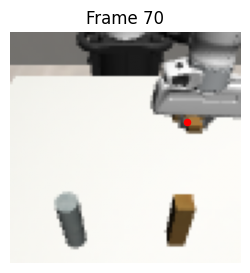

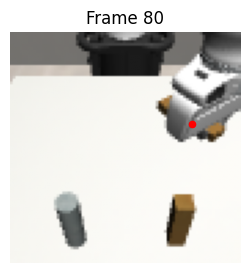

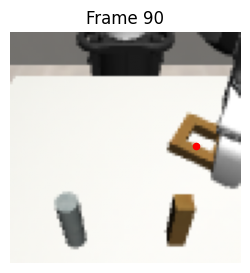

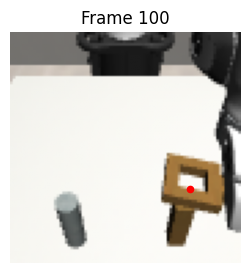

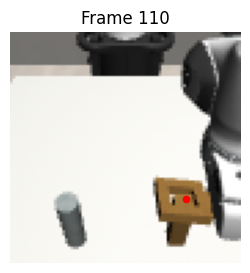

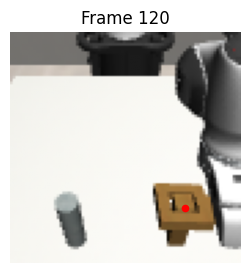

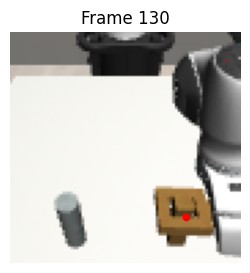

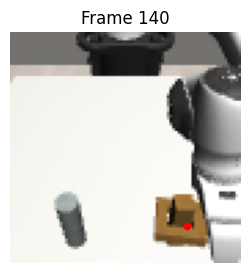

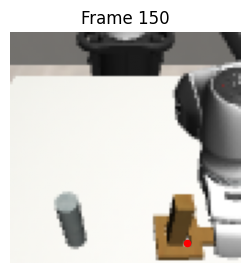

In [13]:
import torch
import matplotlib.pyplot as plt

for i in range(0, len(video), 10):
    frame = video[i]
    point = pred_points[i]

    plt.figure(figsize=(3, 3))
    plt.imshow(frame / 255.0)
    plt.scatter(point[0], point[1], c="red", s=20)
    plt.title(f"Frame {i}")
    plt.axis("off")
    plt.show()